<a href="https://colab.research.google.com/github/anu46464/smart---building--occupancy--detection/blob/main/EDA_and_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 # **Smart Building IoT: Detecting Room Occupancy Using Environmental Sensors.**




# **Data Loading and Initial Inspection**

In [1]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('datatraining.txt')
test_df1 = pd.read_csv('datatest.txt')
test_df2 = pd.read_csv('datatest2.txt')

# Combine test sets for broader evaluation if desired
test_df = pd.concat([test_df1, test_df2])

print("Training data shape:", train_df.shape)
print(train_df.head())

Training data shape: (8143, 7)
                  date  Temperature  Humidity  Light     CO2  HumidityRatio  \
1  2015-02-04 17:51:00        23.18   27.2720  426.0  721.25       0.004793   
2  2015-02-04 17:51:59        23.15   27.2675  429.5  714.00       0.004783   
3  2015-02-04 17:53:00        23.15   27.2450  426.0  713.50       0.004779   
4  2015-02-04 17:54:00        23.15   27.2000  426.0  708.25       0.004772   
5  2015-02-04 17:55:00        23.10   27.2000  426.0  704.50       0.004757   

   Occupancy  
1          1  
2          1  
3          1  
4          1  
5          1  


# **Data Cleaning**

In [2]:
def clean_data(df):
    # Remove index column if it exists (often first column in these txt files)
    if 'Unnamed: 0' in df.columns or df.iloc[:, 0].dtype == 'int64':
         # In your files, the first column appears as a string index "1", "2" etc.
         df = df.drop(df.columns[0], axis=1)

    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])

    # Drop 'HumidityRatio' column as requested by the user
    df = df.drop('HumidityRatio', axis=1)

    # Check for missing values
    if df.isnull().sum().sum() > 0:
        df = df.dropna()

    return df

train_df = clean_data(train_df)
test_df = clean_data(test_df)

# **Exploratory Data Analysis (EDA)**

## **Target distribution graph and Correlation HeatMap**

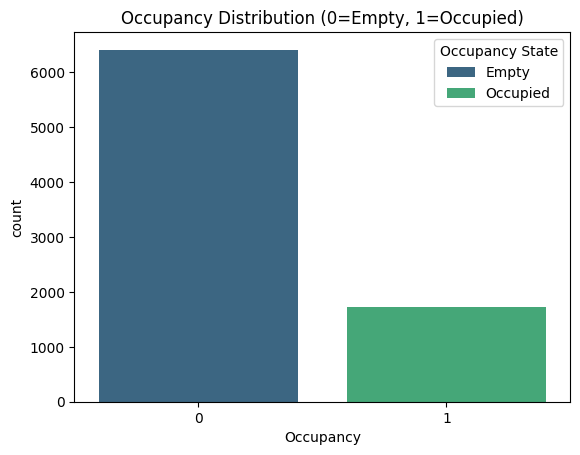

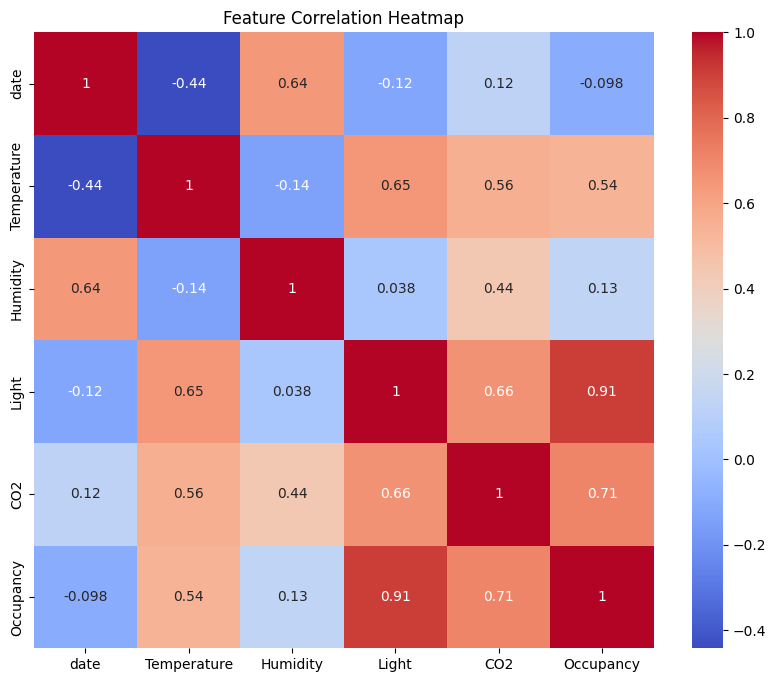

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Check Class Balance
ax = sns.countplot(x='Occupancy', data=train_df, hue='Occupancy', palette='viridis')
plt.title('Occupancy Distribution (0=Empty, 1=Occupied)')
# Get current legend handles and labels
handles, labels = ax.get_legend_handles_labels()
# Map numeric labels to descriptive strings
new_labels = ['Empty' if label == '0' else 'Occupied' for label in labels]
plt.legend(handles, new_labels, title='Occupancy State')
plt.show()

# 2. Correlation Analysis
# Light and CO2 are often the strongest predictors of human presence.
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## **Box Plot**

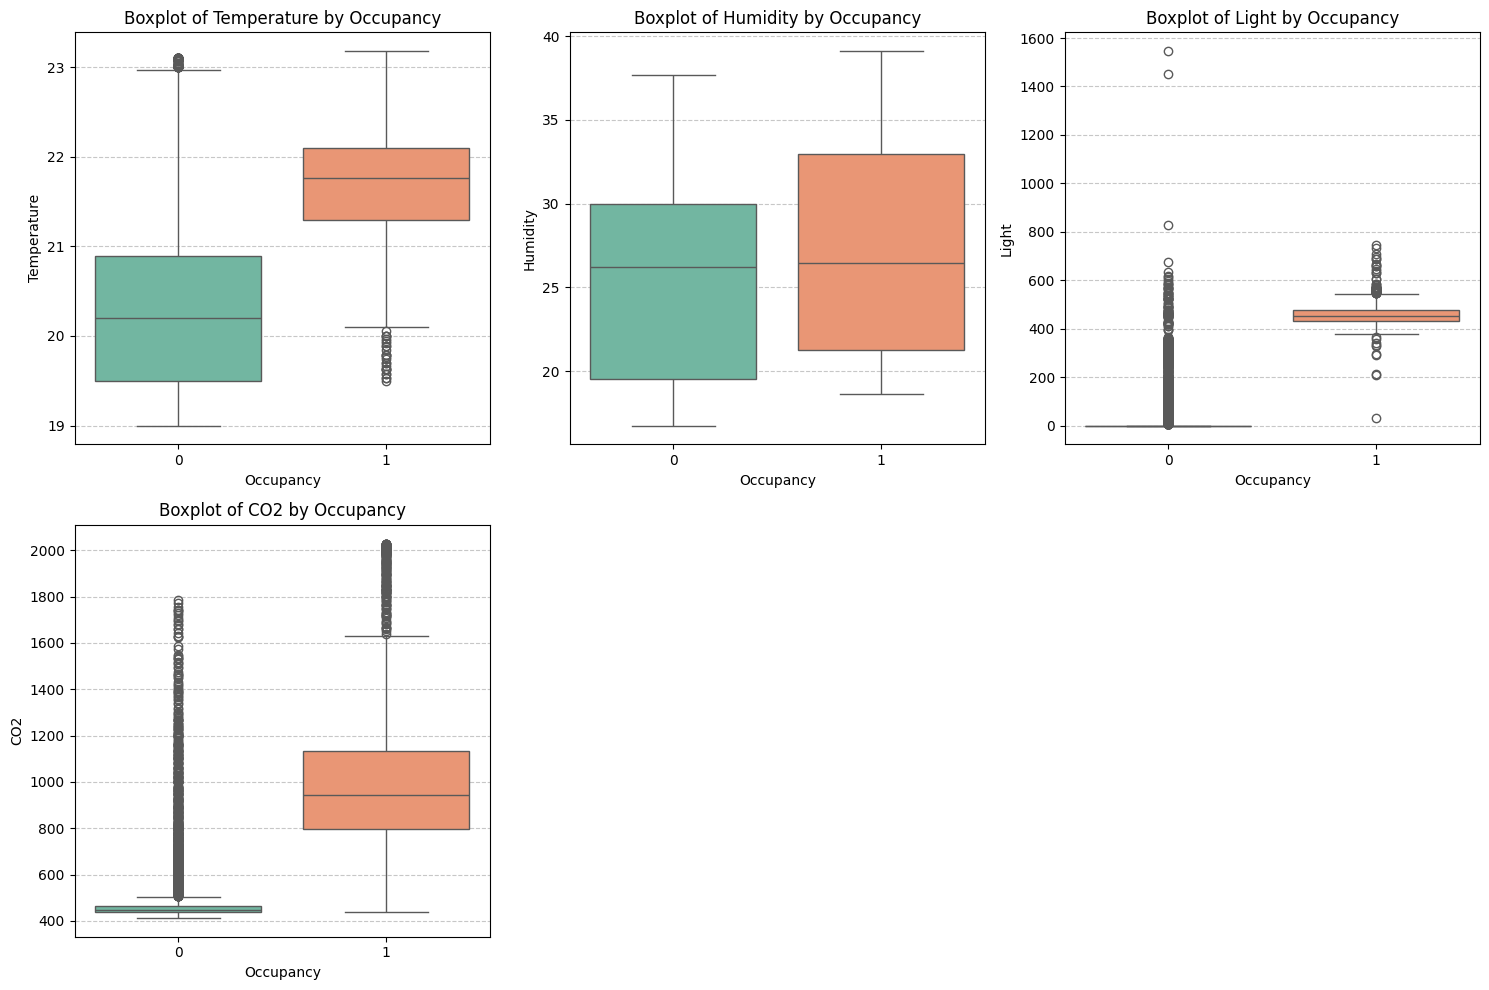

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical features to plot
features = ['Temperature', 'Humidity', 'Light', 'CO2']

# Create a multi-figure box plot
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=train_df[col], x=train_df['Occupancy'], hue=train_df['Occupancy'], palette='Set2', legend=False)
    plt.title(f'Boxplot of {col} by Occupancy')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Scatter Plot**

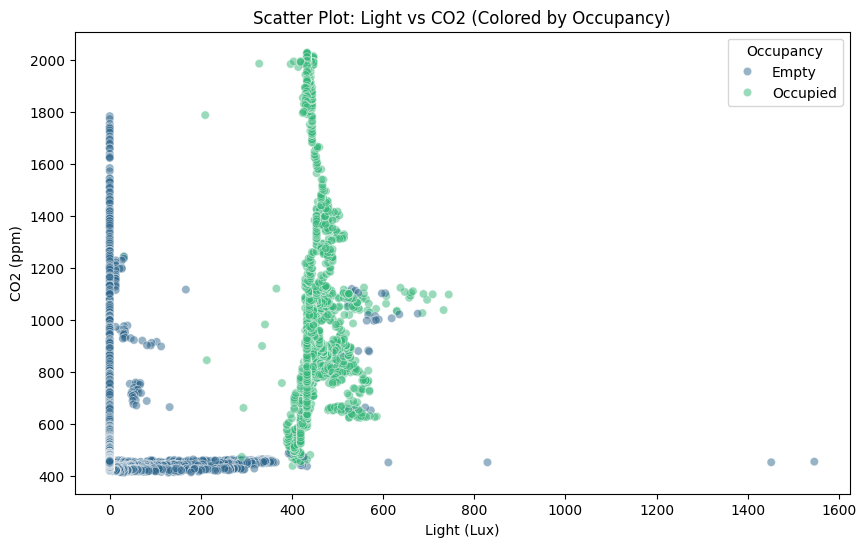

In [5]:
# Scatter plot: Light vs CO2 colored by Occupancy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='Light', y='CO2', hue='Occupancy', alpha=0.5, palette='viridis')
plt.title('Scatter Plot: Light vs CO2 (Colored by Occupancy)')
plt.xlabel('Light (Lux)')
plt.ylabel('CO2 (ppm)')
# Get current legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()
# Map numeric labels to descriptive strings
new_labels = ['Empty' if label == '0' else 'Occupied' for label in labels]
plt.legend(handles, new_labels, title='Occupancy', loc='upper right')
plt.show()

## **Pair Plot**

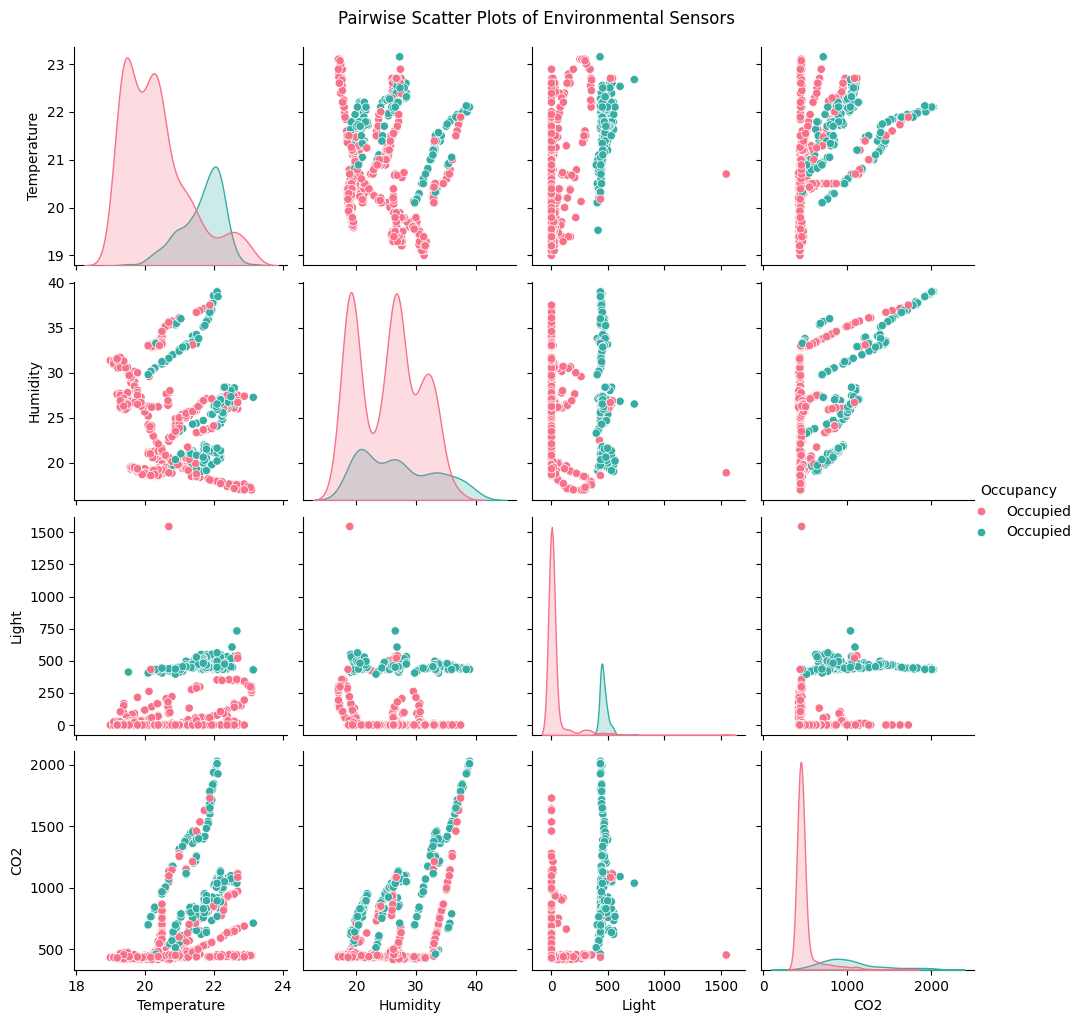

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Sample and Plot ---
# I use a sample of 1000 points to keep the visualization clear
plot = sns.pairplot(
    train_df.sample(1000)[features + ['Occupancy']],
    hue='Occupancy',
    diag_kind='kde',
    palette='husl'
)

# --- Legend Customization ---
# Get current legend handles and labels
handles = plot._legend_data.values()
labels = plot._legend_data.keys()

# Map numeric labels to descriptive strings
new_labels = ['Empty' if label == 0 else 'Occupied' for label in labels]

# Update the legend labels directly in the figure
plot._legend.set_title('Occupancy')
for t, l in zip(plot._legend.texts, new_labels):
    t.set_text(l)

# --- Finalize Plot ---
plt.suptitle('Pairwise Scatter Plots of Environmental Sensors', y=1.02)
plt.show()

# **Feature Engineering**

In [7]:
def add_time_features(df):
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    # Is it a weekend? Occupancy drops significantly then.
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    return df

train_df = add_time_features(train_df)

In [8]:
train_df.head()

,date,Temperature,Humidity,Light,CO2,Occupancy,hour,day_of_week,is_weekend
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,1,17,2,0
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,1,17,2,0
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,1,17,2,0
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,1,17,2,0
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,1,17,2,0


# **Data Preprocessing for Model training**

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Convert date to numeric components
# (Since your head shows hour and day_of_week already exist, we ensure they are numeric)
# If your 'date' column is a string, convert it first:
train_df['date'] = pd.to_datetime(train_df['date'])

# 2. Selecting Features and Target
# We drop 'date' because models can't handle raw timestamps
X = train_df.drop(['Occupancy', 'date'], axis=1)
y = train_df['Occupancy']

# 3. Standardization
# We fit the scaler ONLY on the training data later to avoid data leakage,
# but here is the setup for the numerical columns.
num_cols = ['Temperature', 'Humidity', 'Light', 'CO2']
scaler = StandardScaler()

# 4. Train-Test Split (80% Train, 20% Test)
# We use stratify=y to ensure both sets have the same percentage of occupied/vacant labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Apply Scaling
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (6514, 7)
Testing set shape: (1629, 7)



# **Model Training**
## **Defining and Training Models**

In [10]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

# Dictionary to store trained models and their training times
trained_models = {}
train_times = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    trained_models[name] = model
    train_times[name] = end_time - start_time
    print(f"Finished training {name} in {train_times[name]:.4f} seconds.")

Finished training Logistic Regression in 0.0499 seconds.
Finished training Gradient Boosting in 0.8922 seconds.
Finished training KNN in 0.0098 seconds.


## **Evaluating Model**

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Train Time (s)": train_times[name]
    })

# Display as a clean DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression  0.985267   0.942308  0.991329  0.966197   
1    Gradient Boosting  0.993861   0.977273  0.994220  0.985673   
2                  KNN  0.993861   0.977273  0.994220  0.985673   

   Train Time (s)  
0        0.049935  
1        0.892163  
2        0.009780  


## **Visualization**

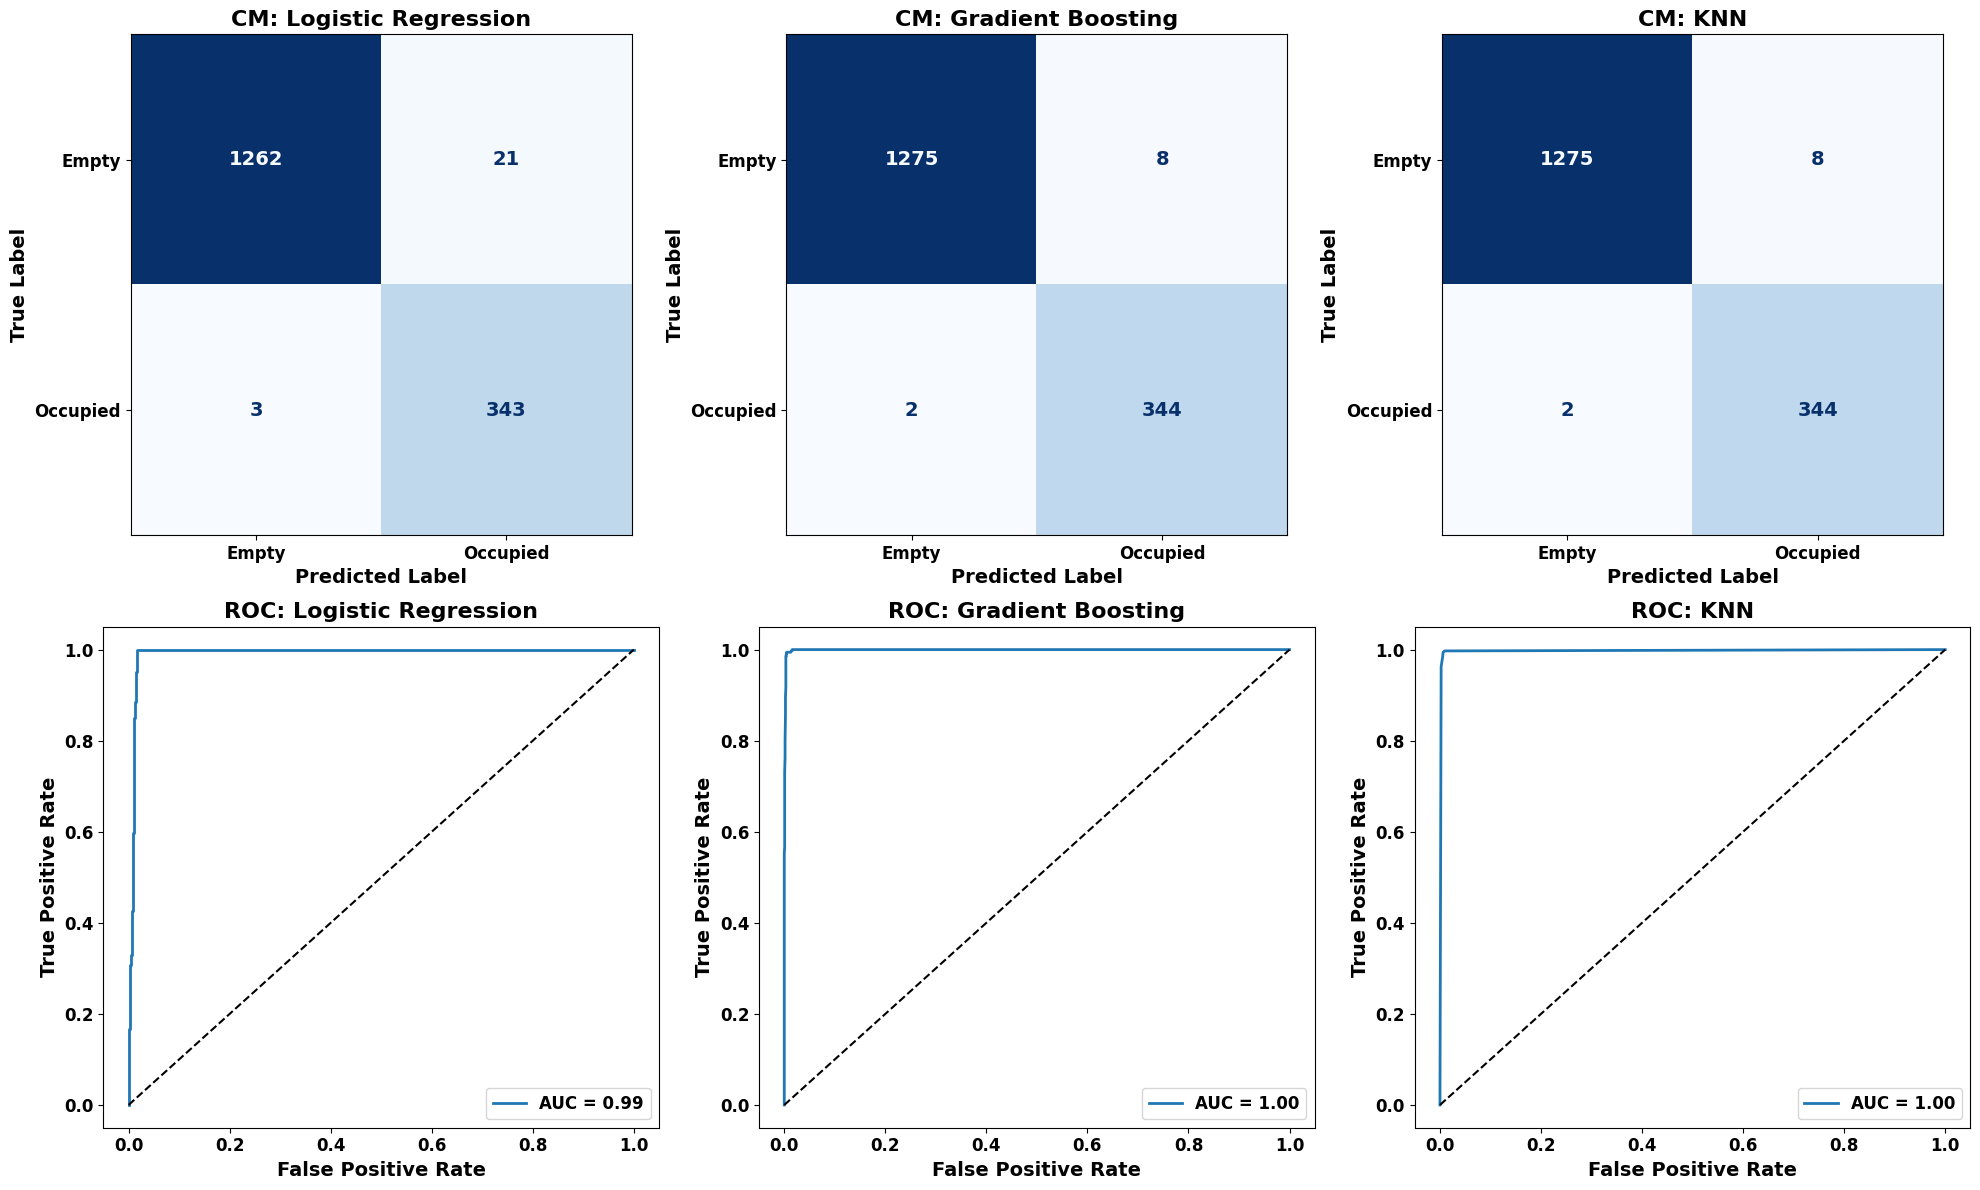

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Increase overall figure size for better readability
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Define Font Styles
title_font = {'weight': 'bold', 'size': 16}
label_font = {'weight': 'bold', 'size': 14}

# Target names for the confusion matrix ticks
target_names = ['Empty', 'Occupied']

for i, (name, model) in enumerate(trained_models.items()):
    # --- 1. Confusion Matrix ---
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Configure display with custom font formatting
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=axes[0, i], cmap='Blues', colorbar=False)

    # Bolding the title and labels for the confusion matrix
    axes[0, i].set_title(f"CM: {name}", fontdict=title_font)
    axes[0, i].set_xlabel('Predicted Label', fontdict=label_font)
    axes[0, i].set_ylabel('True Label', fontdict=label_font)

    # Bolding the tick labels (Empty/Occupied)
    for tick in axes[0, i].get_xticklabels() + axes[0, i].get_yticklabels():
        tick.set_fontweight('bold')
        tick.set_fontsize(12)

    # --- Bolding values inside Confusion Matrix ---
    for text in disp.text_.ravel():
        text.set_weight('bold')
        text.set_fontsize(14)

    # --- 2. ROC Curve ---
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else: # For models without predict_proba
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[1, i].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', linewidth=2)
    axes[1, i].plot([0, 1], [0, 1], 'k--')

    # Bolding Title and Labels
    axes[1, i].set_title(f"ROC: {name}", fontdict=title_font)
    axes[1, i].set_xlabel('False Positive Rate', fontdict=label_font)
    axes[1, i].set_ylabel('True Positive Rate', fontdict=label_font)

    # Bolding the tick labels (0.0, 0.2, etc.)
    for tick in axes[1, i].get_xticklabels() + axes[1, i].get_yticklabels():
        tick.set_fontweight('bold')
        tick.set_fontsize(12)

    axes[1, i].legend(loc='lower right', prop={'weight': 'bold', 'size': 12})

plt.tight_layout()
plt.show()

## **Hyperparameter Optimization using Grid Search**

Optimizing Logistic Regression...
Optimizing Gradient Boosting...
Optimizing KNN...

============================== FINAL EVALUATION ==============================
              Model  F1 Score  Accuracy
Logistic Regression  0.970547  0.987109
  Gradient Boosting  0.985673  0.993861
                KNN  0.985673  0.993861


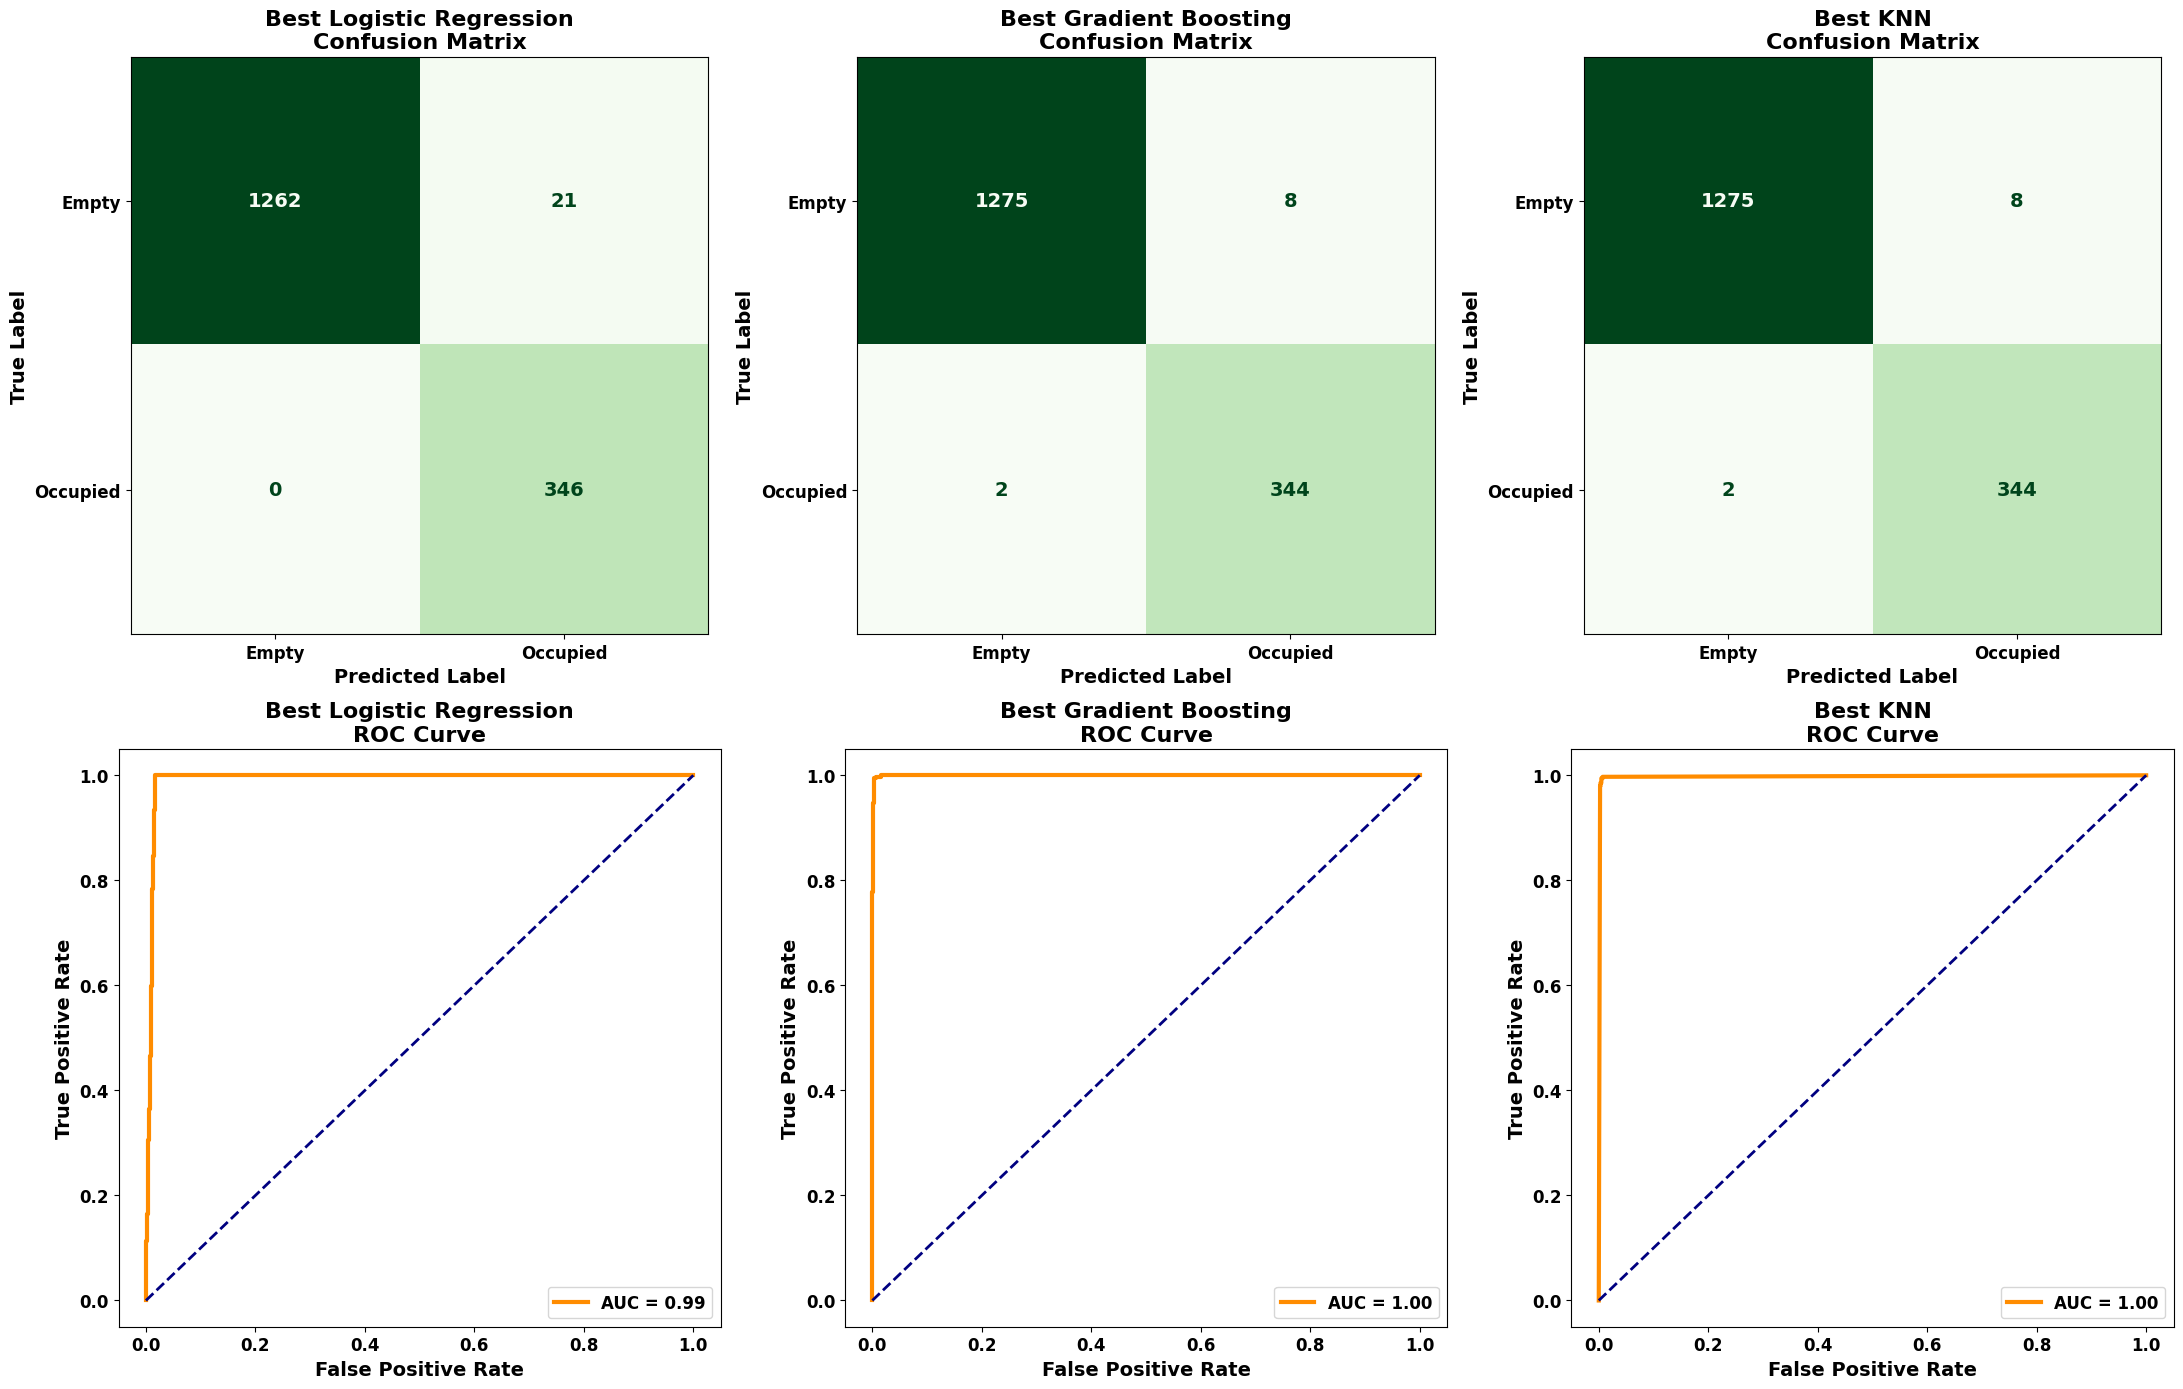

In [13]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# --- Assume X_train, X_test, y_train, y_test are defined here ---

# 1. Define Parameter Grids for each model
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    "KNN": {
        'n_neighbors': [3, 5, 11],
        'weights': ['uniform', 'distance']
    }
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

final_results = []
best_estimators = {}

# --- Visualization Setup (Updated for size and font) ---
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# Define Font Styles
title_font = {'weight': 'bold', 'size': 16}
label_font = {'weight': 'bold', 'size': 14}
tick_font_size = 12
# Target names for mapping
target_names = ['Empty', 'Occupied']

for i, (name, model) in enumerate(models.items()):
    print(f"Optimizing {name}...")

    # 2. Hyperparameter Optimization
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
    start_train = time.time()
    grid_search.fit(X_train, y_train)
    end_train = time.time()

    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model

    # 3. Evaluation
    start_test = time.time()
    y_pred = best_model.predict(X_test)
    end_test = time.time()

    final_results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Train Time (s)": end_train - start_train,
        "Test Time (s)": end_test - start_test
    })

    # --- 4. Visualization - Confusion Matrix (Updated) ---
    cm = confusion_matrix(y_test, y_pred)
    # Pass display_labels here to map 0/1 to Empty/Occupied
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=axes[0, i], cmap='Greens', colorbar=False)

    # Bold Title and Labels
    axes[0, i].set_title(f"Best {name}\nConfusion Matrix", fontdict=title_font)
    axes[0, i].set_xlabel('Predicted Label', fontdict=label_font)
    axes[0, i].set_ylabel('True Label', fontdict=label_font)

    # Bold Tick Labels
    for tick in axes[0, i].get_xticklabels() + axes[0, i].get_yticklabels():
        tick.set_fontweight('bold')
        tick.set_fontsize(tick_font_size)

    # --- Bold values inside Confusion Matrix ---
    for text in disp.text_.ravel():
        text.set_weight('bold')
        text.set_fontsize(14)

    # --- 5. Visualization - ROC Curve (Updated) ---
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
    else:
        y_prob = best_model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[1, i].plot(fpr, tpr, color='darkorange', lw=3, label=f'AUC = {roc_auc:.2f}')
    axes[1, i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    # Bold Title and Labels
    axes[1, i].set_title(f"Best {name}\nROC Curve", fontdict=title_font)
    axes[1, i].set_xlabel('False Positive Rate', fontdict=label_font)
    axes[1, i].set_ylabel('True Positive Rate', fontdict=label_font)

    # Bold Tick Labels
    for tick in axes[1, i].get_xticklabels() + axes[1, i].get_yticklabels():
        tick.set_fontweight('bold')
        tick.set_fontsize(tick_font_size)

    axes[1, i].legend(loc='lower right', prop={'weight': 'bold', 'size': 12})

# Print Table
results_df = pd.DataFrame(final_results)
print("\n" + "="*30 + " FINAL EVALUATION " + "="*30)
print(results_df[['Model', 'F1 Score', 'Accuracy']].to_string(index=False))

plt.tight_layout()
plt.show()

## **K-Fold Cross Validation**

In [14]:
from sklearn.model_selection import cross_validate, KFold
import pandas as pd
import numpy as np

# 1. K-Fold configuration (5 Folds represent a robust standard)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Defining metrics to calculate
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

cv_results_list = []

print("Starting K-Fold Cross Validation...\n")

for name, model in best_estimators.items():
    # 3. Performing Cross Validation
    # We use the 'best_estimators' from the previous grid search for optimal results
    cv_scores = cross_validate(model, X, y, cv=kf, scoring=scoring_metrics)

    # 4. Compiling Mean and Standard Deviation for each metric
    cv_results_list.append({
        "Model": name,
        "Accuracy (Mean)": np.mean(cv_scores['test_accuracy']),
        "Accuracy (Std)": np.std(cv_scores['test_accuracy']),
        "Precision (Mean)": np.mean(cv_scores['test_precision']),
        "Precision (Std)": np.std(cv_scores['test_precision']),
        "Recall (Mean)": np.mean(cv_scores['test_recall']),
        "Recall (Std)": np.std(cv_scores['test_recall']),
        "F1 (Mean)": np.mean(cv_scores['test_f1']),
        "F1 (Std)": np.std(cv_scores['test_f1'])
    })

# 5. Displaying the final results in a clean table
cv_final_df = pd.DataFrame(cv_results_list)

# Formatting for better readability
pd.options.display.float_format = '{:,.4f}'.format
print("="*40 + " K-FOLD CROSS VALIDATION RESULTS " + "="*40)
print(cv_final_df.to_string(index=False))

# Quick Insight for Research Questions
print("\nInsight:")
print("- Low Standard Deviation (Std) suggests the model is consistent across different data subsets.")
print("- High F1-Mean indicates the model is handling the Occupancy detection reliably.")

Starting K-Fold Cross Validation...

======================================== K-FOLD CROSS VALIDATION RESULTS ========================================
              Model  Accuracy (Mean)  Accuracy (Std)  Precision (Mean)  Precision (Std)  Recall (Mean)  Recall (Std)  F1 (Mean)  F1 (Std)
Logistic Regression           0.9875          0.0015            0.9498           0.0113         0.9932        0.0049     0.9709    0.0048
  Gradient Boosting           0.9936          0.0018            0.9822           0.0052         0.9879        0.0058     0.9850    0.0041
                KNN           0.9903          0.0010            0.9654           0.0048         0.9896        0.0023     0.9773    0.0030

Insight:
- Low Standard Deviation (Std) suggests the model is consistent across different data subsets.
- High F1-Mean indicates the model is handling the Occupancy detection reliably.
